In [1]:
from torch_geometric.datasets import TUDataset

# Download and load the dataset
dataset = TUDataset(root='data/TUDataset', name='IMDB-MULTI')

print(dataset)
print(f"Number of graphs: {len(dataset)}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Number of node features: {dataset.num_node_features}")

# Access a single graph
data = dataset[0]
print(data)

Processing...


IMDB-MULTI(1500)
Number of graphs: 1500
Number of classes: 3
Number of node features: 0
Data(edge_index=[2, 42], y=[1], num_nodes=7)


Done!


codes in my repository

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import normalize
from sklearn.metrics import pairwise_distances
from scipy.linalg import eigh

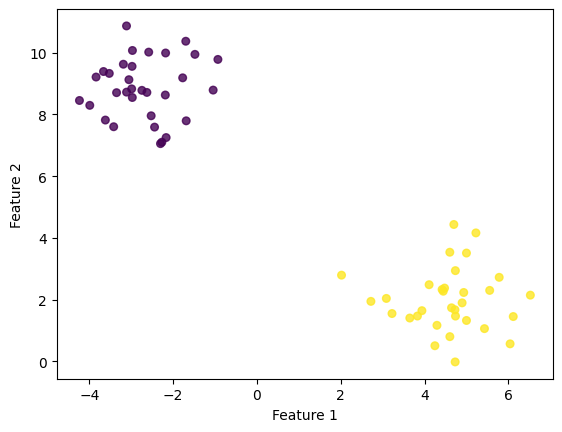

In [35]:
# data generation
X, Y = datasets.make_blobs(n_samples=64, centers=2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', s=30, alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [36]:
# A -> D -> L
A = np.exp(-pairwise_distances(X, metric='euclidean'))
D = np.diag(np.sum(A, axis=1))
L = D - A

In [37]:
import pennylane as qml
import math

n = int(math.log2(L.shape[0]))
dev = qml.device("default.qubit", wires=n)
LCU_coeffs, LCU_ops = qml.pauli_decompose(L).terms()
H = qml.ops.LinearCombination(LCU_coeffs, LCU_ops)

tau = 5

@qml.qnode(dev)
def sample_state():
    for i in range(n):
        qml.Hadamard(wires=i)
    qml.ApproxTimeEvolution(H, tau, 1)
    return qml.state()

psi = sample_state()

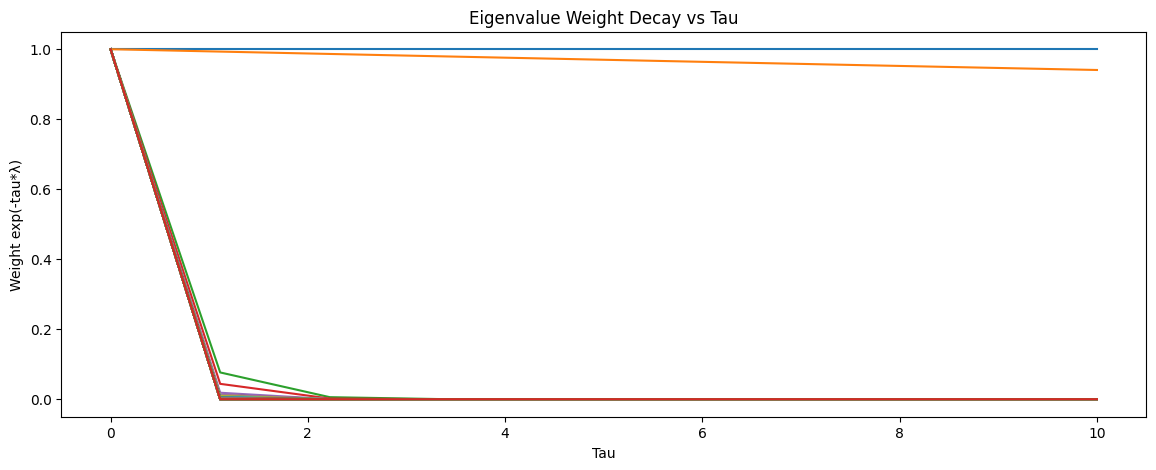

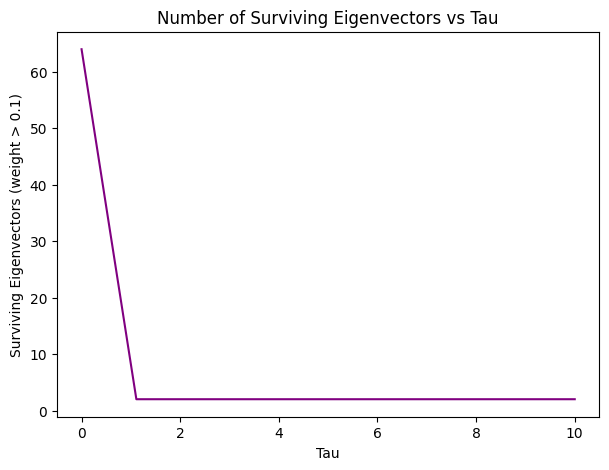

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

eigenvalues = np.sort(np.linalg.eigvalsh(L))

taus = np.linspace(0, 10, 10)
weights = np.array([[np.exp(-tau * lam) for lam in eigenvalues] for tau in taus])

# Survival count (threshold = 0.1)
threshold = 0.1
num_surviving = (weights > threshold).sum(axis=1)

# Plot decay curves
plt.figure(figsize=(14,5))
for i, lam in enumerate(eigenvalues):
    plt.plot(taus, weights[:, i], label=f"λ{i+1}={lam:.2f}")
plt.title("Eigenvalue Weight Decay vs Tau")
plt.xlabel("Tau")
plt.ylabel("Weight exp(-tau*λ)")
# plt.legend()
plt.show()

# Plot survival count
plt.figure(figsize=(7,5))
plt.plot(taus, num_surviving, color='purple')
plt.title("Number of Surviving Eigenvectors vs Tau")
plt.xlabel("Tau")
plt.ylabel("Surviving Eigenvectors (weight > 0.1)")
plt.show()


In [39]:
import numpy as np

def find_tau(L, num_surviving, threshold=0.1, tau_max=20, steps=1000):
    """
    Find tau such that the number of surviving eigenvectors (weights > threshold)
    equals num_surviving.

    Parameters
    ----------
    L : np.ndarray
        Laplacian matrix of the graph.
    num_surviving : int
        Desired number of surviving eigenvectors.
    threshold : float, optional
        Survival threshold for weight exp(-tau * lambda_i). Default = 0.1.
    tau_max : float, optional
        Maximum tau to search. Default = 20.
    steps : int, optional
        Resolution of tau search. Default = 1000.

    Returns
    -------
    tau : float
        Approximate tau value that yields the desired number of surviving eigenvectors.
        Returns None if no tau satisfies the condition.
    """

    # Compute eigenvalues
    eigenvalues = np.sort(np.linalg.eigvalsh(L))

    # Search over tau values
    taus = np.linspace(0, tau_max, steps)
    for tau in taus:
        weights = np.exp(-tau * eigenvalues)
        surviving = np.sum(weights > threshold)
        if surviving == 2:
            return tau

    return None

find_tau(L, 3, threshold=0.1, tau_max=20, steps=1000)

np.float64(1.001001001001001)